Clusterability and mixability looked at the global distribution of cells in PC space. EMD loss compared to baseline models similarly looked at the accuracy of the predicted global distribution. Here, we like pairwise distances between single-cells in the full TF activity space. We use euclidean distance as our distance metric.  

We have two expectations:
1. Distances within a cell type + stimulation condition are smaller than distances within a cell type across stimulations. 
2. Distances within a cell type + stimulation condition are smaller than a null distribution of distances between a random subset of cells of the same size. 

For each cell type, we will compared the predicted values of a given stimulation  to the actual values of the opposite stimulation. 

We will also need to set up baselines which use the actual data of the same condition as the predicted, to assess that our expectations are in fact met and how closely the predicted values compare.  

In [1]:
import os

import pandas as pd
import scanpy as sc
import numpy as np

import torch

from scipy import stats
from statsmodels.stats.multitest import multipletests
from cliffs_delta import cliffs_delta

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
import seaborn as sns

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS.preprocess import calculate_pairwise_distances, get_upper_triangle#, cohen_d

sys.path.insert(1, './')
from assessment_utils import get_prediction, rev_stim

In [3]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

author = 'Kang'
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [4]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

Params:

In [36]:
distance_metric = 'euclidean'

Load data:

In [5]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [35]:
trainer = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))
mod = trainer.mod

# test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
# test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())
# train_cells_all = [barcode for barcode in tf_adata.obs_names if barcode not in test_cells]

test_cells = trainer.X_test.index.tolist()
train_cells_all = trainer.X_train.index.tolist()
test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())

#### Get the predictions and concordance:

As described in Notebook 06E, for each cell type, we get the counterfactual from all in-distribution or within a cell type ("opposite").

In [67]:
cf_map = {'in_distribution': train_cells_all}
counterfactual_types = list(cf_map.keys()) + ['opposite']

tf_predicted_res = {}
for counterfactual_type in counterfactual_types:
    tf_adata_predicted = get_prediction(mod = mod, 
                                        tf_adata = tf_adata, 
                                        counterfactual_type = counterfactual_type, 
                                        cf_map = cf_map, 
                                        train_cells_all = train_cells_all, 
                                        test_conds = test_conds
                                        )
    tf_predicted_res[counterfactual_type] = tf_adata_predicted

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


#### Expectation 1: Within stimulation distances < across stimulation distances

In [84]:
def expectation_1_distances(predicted_df, actual_df, ctrl_df):
    
    across_actual = calculate_pairwise_distances(df1 = actual_df, 
                                                df2 = ctrl_df, 
                                                distance_metric = distance_metric, 
                                                axis = 0, 
                                                invert_corr = True).values.flatten()
    across_predicted = calculate_pairwise_distances(df1 = predicted_df, 
                                                df2 = ctrl_df, 
                                                distance_metric = distance_metric, 
                                                axis = 0, 
                                                invert_corr = True).values.flatten()

    within_actual = get_upper_triangle(calculate_pairwise_distances(df1 = actual_df, 
                                                                    df2 = None, 
                                                                    distance_metric = distance_metric, 
                                                                    axis = 0, 
                                                                    invert_corr = True
                                                                   )
                                      )

    within_predicted = get_upper_triangle(calculate_pairwise_distances(df1 = predicted_df, 
                                                                       df2 = None,
                                                                       distance_metric = distance_metric, 
                                                                       axis = 0, 
                                                                       invert_corr = True
                                                                      )
                                      )

#     within_ctrl = get_upper_triangle(calculate_pairwise_distances(df1 = ctrl_df, 
#                                                                   df2 = None,
#                                                                   distance_metric = distance_metric, 
#                                                                   axis = 0, 
#                                                                   invert_corr = True
#                                                                  )
#                                      )
    
    e1_res = {'Across Actual': across_actual, 
              'Within Actual': within_actual, 
             'Across Predicted': across_predicted, 
             'Within Predicted': within_predicted
             } 
            # 'Within Ctrl': within_ctrl}
    
    return e1_res

In [172]:
e1_res_all = {}
for counterfactual_type, tf_adata_predicted in tf_predicted_res.items():
    e1_res_conds = {}
    for cond in test_conds:
        stim, cell_type = cond.split('^')
        ctrl_cond = '^'.join([rev_stim[stim], cell_type])

        predicted_df = tf_adata_predicted[tf_adata_predicted.obs.condition == cond, :].to_df()
        actual_df = tf_adata[tf_adata.obs.condition == cond, :].to_df()
        ctrl_df = tf_adata[tf_adata.obs.condition == ctrl_cond].to_df()

        e1_res = expectation_1_distances(predicted_df, actual_df, ctrl_df)
        e1_res_conds[cond] = e1_res
    e1_res_all[counterfactual_type] = e1_res_conds

Visualization: We expect the across to be greater than the within for both actual and predicted. We test this with a one-sided MWU. We also expec the within actual and within predicted to be equal. We test this with a two-sided MWU. We quantiyf differences with Cohen's D. Statistics are run on all data; violin plots are visualized on a subset of 1e5 distances to allow the plotting to run in a reasonable time. 

In [162]:
subset_size = int(1e2)

In [163]:
comparisons = [('Across Actual', 'Within Actual'), 
              ('Across Predicted', 'Within Predicted'), 
              ('Within Actual', 'Within Predicted')]
alternatives = dict(zip(comparisons, ['greater', 'greater', 'two-sided']))

''

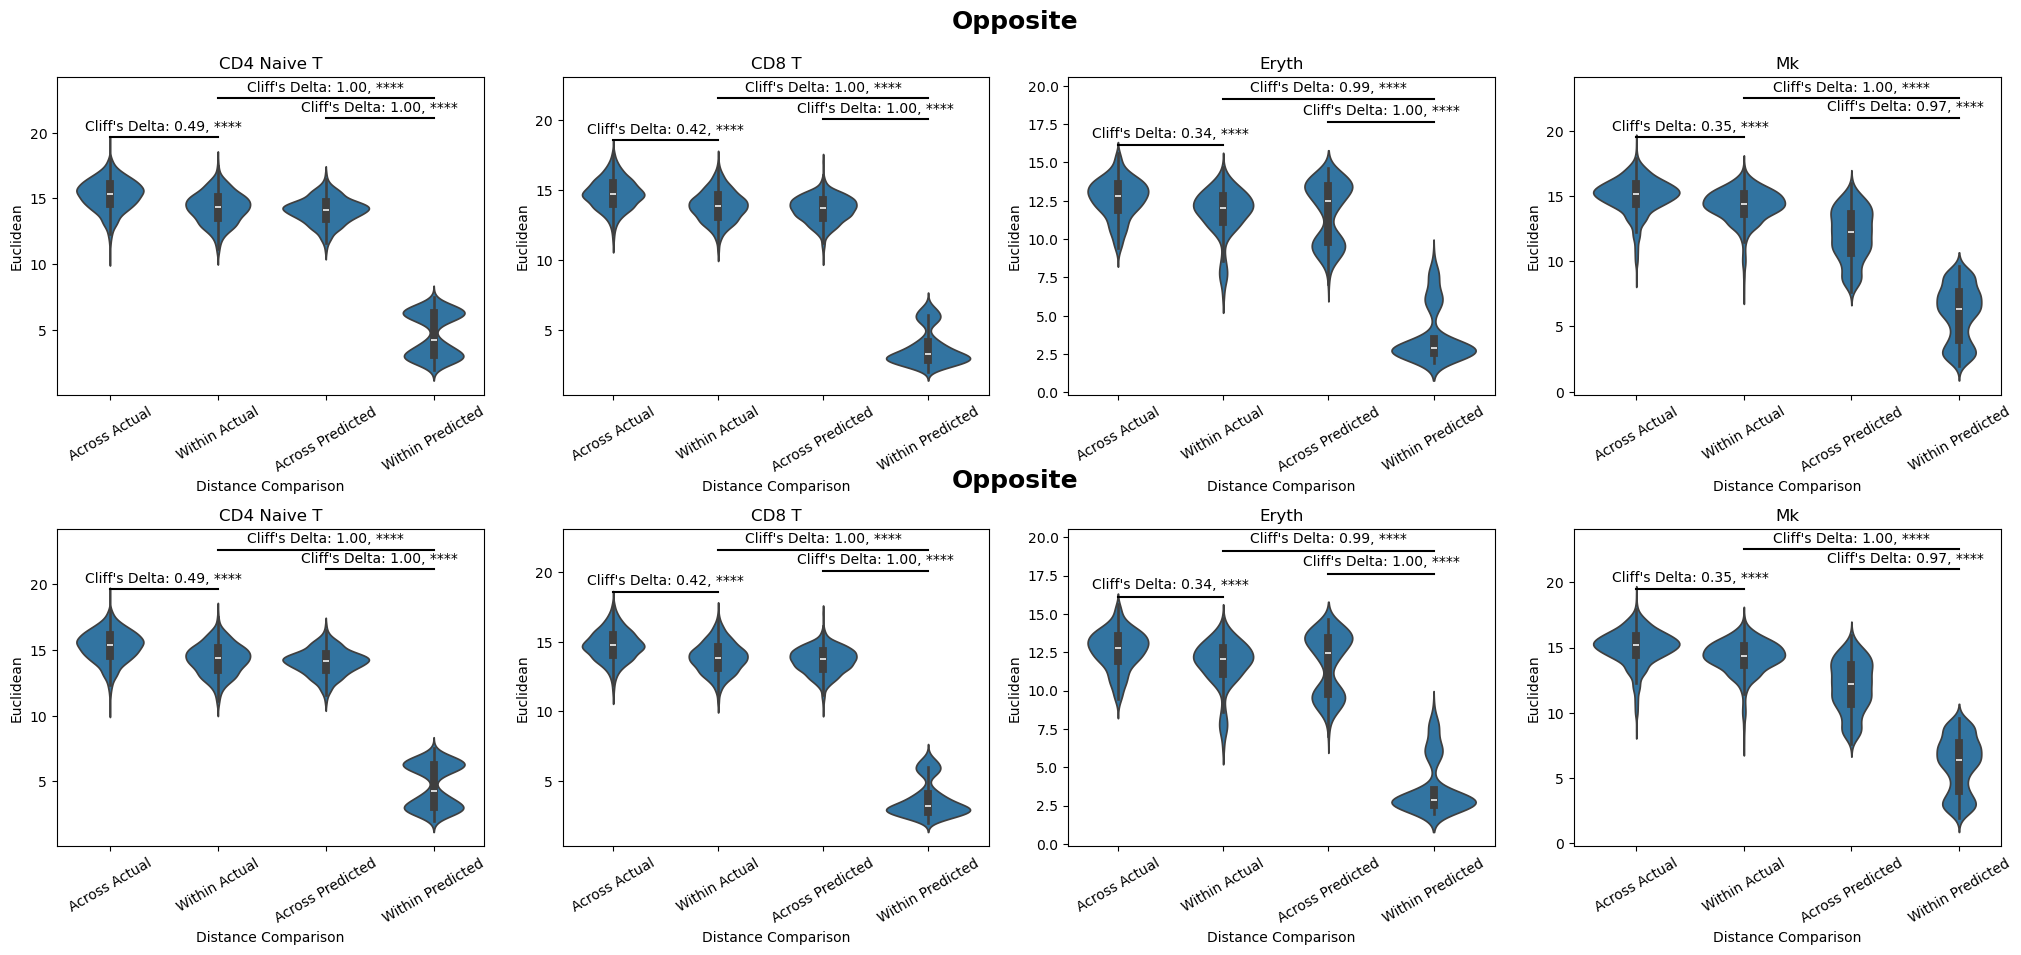

In [181]:
ncols = len(e1_res_conds)
nrows = len(e1_res_all)
fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (ncols * 5.1, nrows*5.1))

counterfactual_type_title = {'in_distribution': 'In Disribution', 'opposite': 'Opposite'}
title_coords = [0.92, 0.47]

for i, (counter_factual_type, e1_res) in enumerate(e1_res_all.items()):
    for j, (cond, e1_res) in enumerate(e1_res_conds.items()):
        # get statistics
        pvals = []
        effect_size = []
        for comp, alternative in alternatives.items():
            _, pval = stats.mannwhitneyu(e1_res[comp[0]], e1_res[comp[1]], alternative = alternative)
            pvals.append(pval)
            effect_size.append(cliffs_delta(e1_res[comp[0]], e1_res[comp[1]])[0])
#             effect_size.append(cohen_d(e1_res[comp[0]], e1_res[comp[1]]))
        _, fdr, _, _ = multipletests(pvals, method='fdr_bh')

        # subset for reasonable visualization
        e1_res_viz = {}
        for k,v in e1_res.items():
            np.random.seed(seed)
            if len(v) > subset_size:
                v = np.random.choice(v, subset_size, replace = False)
            e1_res_viz[k] = v

        # plot violins
        categories = []
        violin_data = []
        for category, values in e1_res_viz.items():
            categories.extend([category] * len(values))
            violin_data.extend(values)

        sns.violinplot(x=categories, y=violin_data, ax = ax[i,j])

        # annotate statistics
        xtick_positions = [tick.get_position()[0] for tick in ax[i,j].get_xticklabels()]
        x_pos_dict = {label: pos for label, pos in zip(e1_res.keys(), range(len(e1_res)))}
        annotation_y_offset = 1.5
        annotation_y_offset_2 = 0.5
        max_y = max([max(values) for values in e1_res_viz.values()]) + annotation_y_offset_2

        for idx, ((group1, group2), p_value, effect) in enumerate(zip(comparisons, fdr, effect_size)):

            significance = "N.S."
            if p_value <= 1e-4:
                significance = "****"
            elif p_value <= 0.001:
                significance = "***"
            elif p_value <= 0.01:
                significance = "**"
            elif p_value <= 0.1:
                significance = "*"

            x1 = x_pos_dict[group1]
            x2 = x_pos_dict[group2]
            x_mid = (x1 + x2) / 2

            y_pos = max_y + (idx * annotation_y_offset)
            ax[i,j].plot([x1, x2], [y_pos, y_pos], color='black', lw=1.5)
            annotation_text = "Cliff's Delta: {:.2f}, ".format(effect) + significance #'Cohen'f"Cohen's d={effect:.2f}"
            ax[i,j].text(x_mid, y_pos + annotation_y_offset_2, annotation_text, ha='center', color='black', fontsize=10)
            #     ax[i,j].text(x_mid, y_pos + 0.3, f"Cohen's d={effect:.2f}", ha='center', color='black', fontsize=10)


        ymin, ymax = ax[i,j].get_ylim()
        ax[i,j].set_ylim(ymin, ymax + annotation_y_offset_2)
        ax[i,j].set_xlabel("Distance Comparison")
        ax[i,j].set_ylabel(distance_metric.capitalize())
        ax[i,j].set_title(cond.split('^')[1])
        ax[i,j].xaxis.set_major_locator(FixedLocator(ax[i,j].get_xticks()))
        ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), rotation=30, ha='center')
        
    fig.text(0.5, title_coords[i], 
             counterfactual_type_title[counterfactual_type], 
             ha='center', va='center', fontsize=18, fontweight='bold')

fig.tight_layout(rect=[0, 0, 1, 0.9])
;